# MovieLens 32M: Exploratory Data Analysis (EDA)

The goal of this notebook is to understand the shape, distribution, and sparsity of the MovieLens 32M dataset. To handle the 32 million ratings efficiently without running out of memory, we will use **Polars** with LazyFrames for data manipulation rather than Pandas.

Dataset files:
* `ratings.csv`: User ratings for movies.
* `movies.csv`: Movie titles and genres.
* `tags.csv`: User-generated metadata tags.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Ingestion (Lazy Loading)
Instead of loading the entire CSVs into RAM immediately, we use `pl.scan_csv()` to create a LazyFrame. Polars will build an optimized query plan and only execute it when we call `.collect()`. 

We will also define schemas to try and optimize memory usage.

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [3]:
DATA_DIR = "./data/ml-32m/"

ratings_lf = pl.scan_csv(
    f"{DATA_DIR}ratings.csv",
    schema_overrides={
        "userId": pl.Int32,
        "movieId": pl.Int32,
        "rating": pl.Float32,
        "timestamp": pl.Int64
    }
)

movies_lf = pl.scan_csv(
    f"{DATA_DIR}movies.csv",
    schema_overrides={
        "movieId": pl.Int32,
        "title": pl.Utf8,
        "genres": pl.Utf8
    }
)

tags_lf = pl.scan_csv(
    f"{DATA_DIR}tags.csv",
    schema_overrides={
        "userId": pl.Int32,
        "movieId": pl.Int32,
        "tag": pl.Utf8,
        "timestamp": pl.Int64
    }
)

print("LazyFrames created successfully.")

LazyFrames created successfully.


## 2. Initial Inspection
Let's take a quick look at the first few rows of our ratings data. Calling `.head(10).collect()` tells Polars to only read the first 10 rows of the CSV, which is practically instantaneous.

Timestamps represent seconds since midnight Coordinated Universal Time (UTC) of January 1, 1970. We will convert these to human-readable datetimes.

In [4]:
ratings_lf.head(10).collect()

userId,movieId,rating,timestamp
i32,i32,f32,i64
1,17,4.0,944249077
1,25,1.0,944250228
1,29,2.0,943230976
1,30,5.0,944249077
1,32,5.0,943228858
1,34,2.0,943228491
1,36,1.0,944249008
1,80,5.0,944248943
1,110,3.0,943231119


In [5]:
ratings_lf = ratings_lf.with_columns(
    pl.from_epoch(pl.col("timestamp"), time_unit="s").alias("datetime")
)

ratings_lf.head(10).collect()

userId,movieId,rating,timestamp,datetime
i32,i32,f32,i64,datetime[μs]
1,17,4.0,944249077,1999-12-03 19:24:37
1,25,1.0,944250228,1999-12-03 19:43:48
1,29,2.0,943230976,1999-11-22 00:36:16
1,30,5.0,944249077,1999-12-03 19:24:37
1,32,5.0,943228858,1999-11-22 00:00:58
1,34,2.0,943228491,1999-11-21 23:54:51
1,36,1.0,944249008,1999-12-03 19:23:28
1,80,5.0,944248943,1999-12-03 19:22:23
1,110,3.0,943231119,1999-11-22 00:38:39


## 3. Ratings Distribution
Ratings are made on a 5-star scale, with half-star increments (0.5 stars - 5.0 stars). Let's analyze the distribution of these ratings to see if users tend to be generous or critical.

In [6]:
rating_counts = (
    ratings_lf
    .group_by("rating")
    .agg(pl.count("userId").alias("count"))
    .sort("rating")
    .collect()
)

rating,count
f32,u32
0.5,525132
1.0,946675
1.5,531063
2.0,2028622
2.5,1685386
3.0,6054990
3.5,4290105
4.0,8367654
4.5,2974000


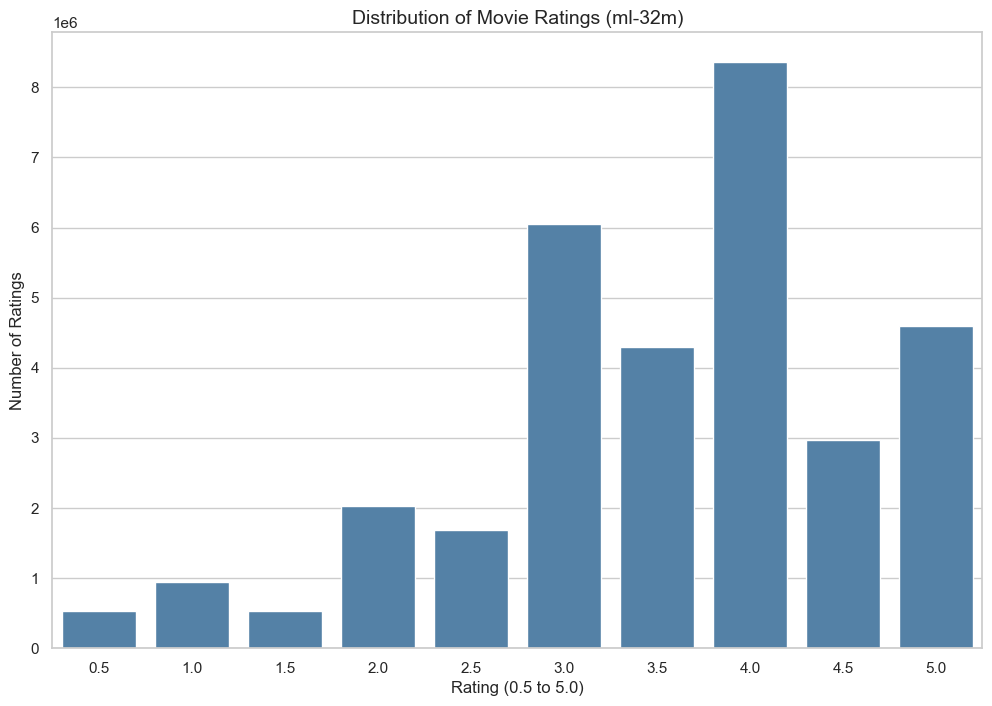

In [7]:
display(rating_counts)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=rating_counts["rating"].to_list(), 
    y=rating_counts["count"].to_list(), 
    color="steelblue"
)
plt.title("Distribution of Movie Ratings (ml-32m)", fontsize=14)
plt.xlabel("Rating (0.5 to 5.0)", fontsize=12)
plt.ylabel("Number of Ratings", fontsize=12)
plt.show()

## 4. Dataset Sparsity
Recommender systems suffer from the "cold start" and sparsity problems. We need to calculate the exact sparsity of our user-item matrix. 

In [8]:
sparsity_stats = (
    ratings_lf
    .select(
        pl.col("userId").n_unique().alias("unique_users"),
        pl.col("movieId").n_unique().alias("unique_movies"),
        pl.len().alias("total_ratings")
    )
    .collect()
)

n_users = sparsity_stats["unique_users"][0]
n_movies = sparsity_stats["unique_movies"][0]
n_ratings = sparsity_stats["total_ratings"][0]

matrix_size = n_users * n_movies
sparsity = 1 - (n_ratings / matrix_size)

print(f"Total Unique Users: {n_users:,}")
print(f"Total Unique Movies: {n_movies:,}")
print(f"Total Ratings: {n_ratings:,}")
print("-" * 30)
print(f"Matrix Sparsity: {sparsity * 100:.4f}%")

Total Unique Users: 200,948
Total Unique Movies: 84,432
Total Ratings: 32,000,204
------------------------------
Matrix Sparsity: 99.8114%


## 5. The Long Tail: Movie Popularity
In most recommendation systems, a tiny fraction of items gets the vast majority of interactions (blockbusters), while the rest form a "long tail" of niche content. 

Let's group our ratings by `movieId` to see how many ratings the average movie gets, and identify if we need to filter out ultra-obscure movies before modeling to reduce noise.

In [9]:
movie_activity = (
    ratings_lf
    .group_by("movieId")
    .agg(pl.count("userId").alias("num_ratings"))
    .join(
        movies_lf.select(["movieId", "title"]), 
        on="movieId", 
        how="left"
    )
    .select(["movieId", "title", "num_ratings"])
    .sort("num_ratings", descending=True)
    .collect()
)

Top 5 Most Rated Movies:


movieId,title,num_ratings
i32,str,u32
318,"""Shawshank Redemption, The (199…",102929
356,"""Forrest Gump (1994)""",100296
296,"""Pulp Fiction (1994)""",98409
2571,"""Matrix, The (1999)""",93808
593,"""Silence of the Lambs, The (199…",90330
260,"""Star Wars: Episode IV - A New …",85010
2959,"""Fight Club (1999)""",77332
480,"""Jurassic Park (1993)""",75233
527,"""Schindler's List (1993)""",73849


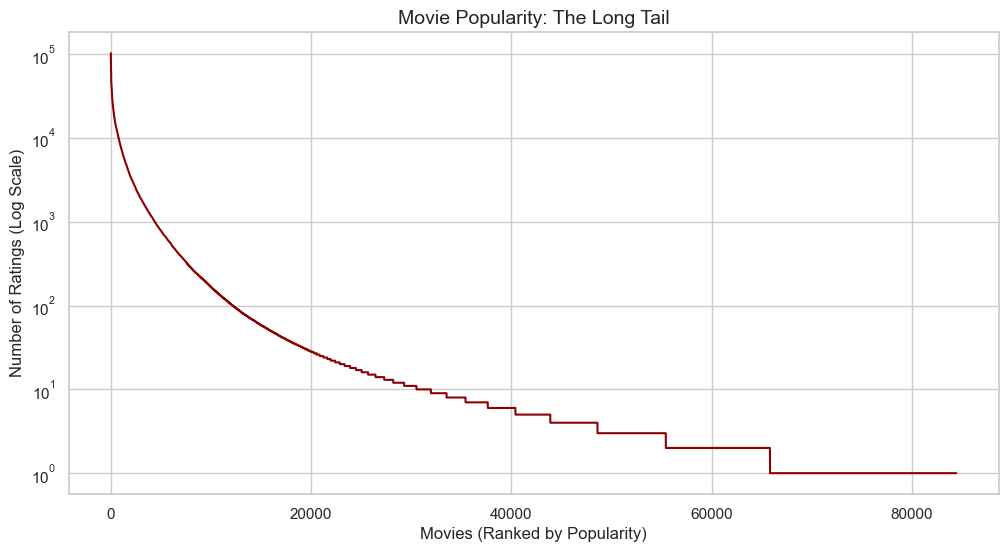


Movie Rating Statistics:


statistic,num_ratings
str,f64
"""count""",84432.0
"""null_count""",0.0
"""mean""",379.005638
"""std""",2592.439791
"""min""",1.0
"""25%""",2.0
"""50%""",5.0
"""75%""",25.0
"""max""",102929.0


In [10]:
print("Top 5 Most Rated Movies:")
display(movie_activity.head(10))

plt.figure(figsize=(12, 6))
plt.plot(movie_activity["num_ratings"].to_list(), color='darkred')
plt.title("Movie Popularity: The Long Tail", fontsize=14)
plt.xlabel("Movies (Ranked by Popularity)", fontsize=12)
plt.ylabel("Number of Ratings (Log Scale)", fontsize=12)
plt.yscale('log') 
plt.show()

print("\nMovie Rating Statistics:")
display(movie_activity.select(pl.col("num_ratings")).describe())

## 6. User Activity Distribution
We know from the dataset documentation that all selected users were required to have rated at least 20 movies. Let's verify this and see if we have "power users" who have rated thousands of movies, as they can heavily skew collaborative filtering algorithms.

In [11]:
user_activity = (
    ratings_lf
    .group_by("userId")
    .agg(pl.count("movieId").alias("num_ratings"))
    .sort("num_ratings", descending=True)
    .collect()
)
p99p9 = user_activity.select(pl.col("num_ratings").quantile(0.999)).item()
p99 = user_activity.select(pl.col("num_ratings").quantile(0.99)).item()
p95 = user_activity.select(pl.col("num_ratings").quantile(0.95)).item()

display(user_activity.select(pl.col("num_ratings")).describe())

statistic,num_ratings
str,f64
"""count""",200948.0
"""null_count""",0.0
"""mean""",159.246193
"""std""",282.025462
"""min""",20.0
"""25%""",36.0
"""50%""",73.0
"""75%""",167.0
"""max""",33332.0


99.9% of users have rated 2995.0 or fewer movies.
99% of users have rated 1290.0 or fewer movies.
95% of users have rated 571.0 or fewer movies.


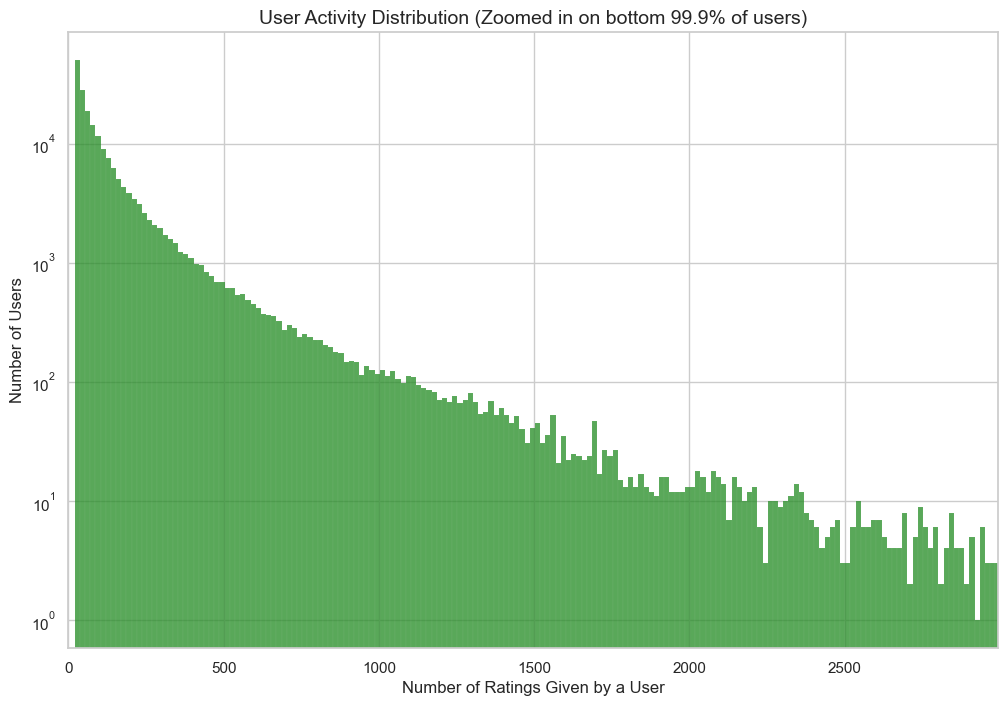

In [12]:
print(f"99.9% of users have rated {p99p9} or fewer movies.")
print(f"99% of users have rated {p99} or fewer movies.")
print(f"95% of users have rated {p95} or fewer movies.")

plt.figure(figsize=(12, 8))
sns.histplot(
    x=user_activity["num_ratings"].to_list(), 
    bins=2000, 
    color='forestgreen'
)
plt.title(f"User Activity Distribution (Zoomed in on bottom 99.9% of users)", fontsize=14)
plt.xlabel("Number of Ratings Given by a User", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.yscale('log') 
plt.xlim(0, p99p9)
plt.show()

## 7. Temporal Analysis
The dataset spans ~28 years (1995–2023). Temporal dynamics matter for recommender systems: user preferences drift, rating volumes spike on release dates, and recent ratings may be more signal-rich. Let's examine rating volume over time and average rating trends by year.

In [13]:
ratings_over_time = (
    ratings_lf
    .with_columns(
        pl.col("datetime").dt.year().alias("year"),
        pl.col("datetime").dt.month().alias("month")
    )
    .group_by(["year", "month"])
    .agg(
        pl.len().alias("num_ratings"),
        pl.col("rating").mean().alias("avg_rating")
    )
    .sort(["year", "month"])
    .collect()
)

ratings_over_time = ratings_over_time.with_columns(
    (pl.col("year").cast(pl.Utf8) + "-" + pl.col("month").cast(pl.Utf8).str.zfill(2)).alias("year_month")
)

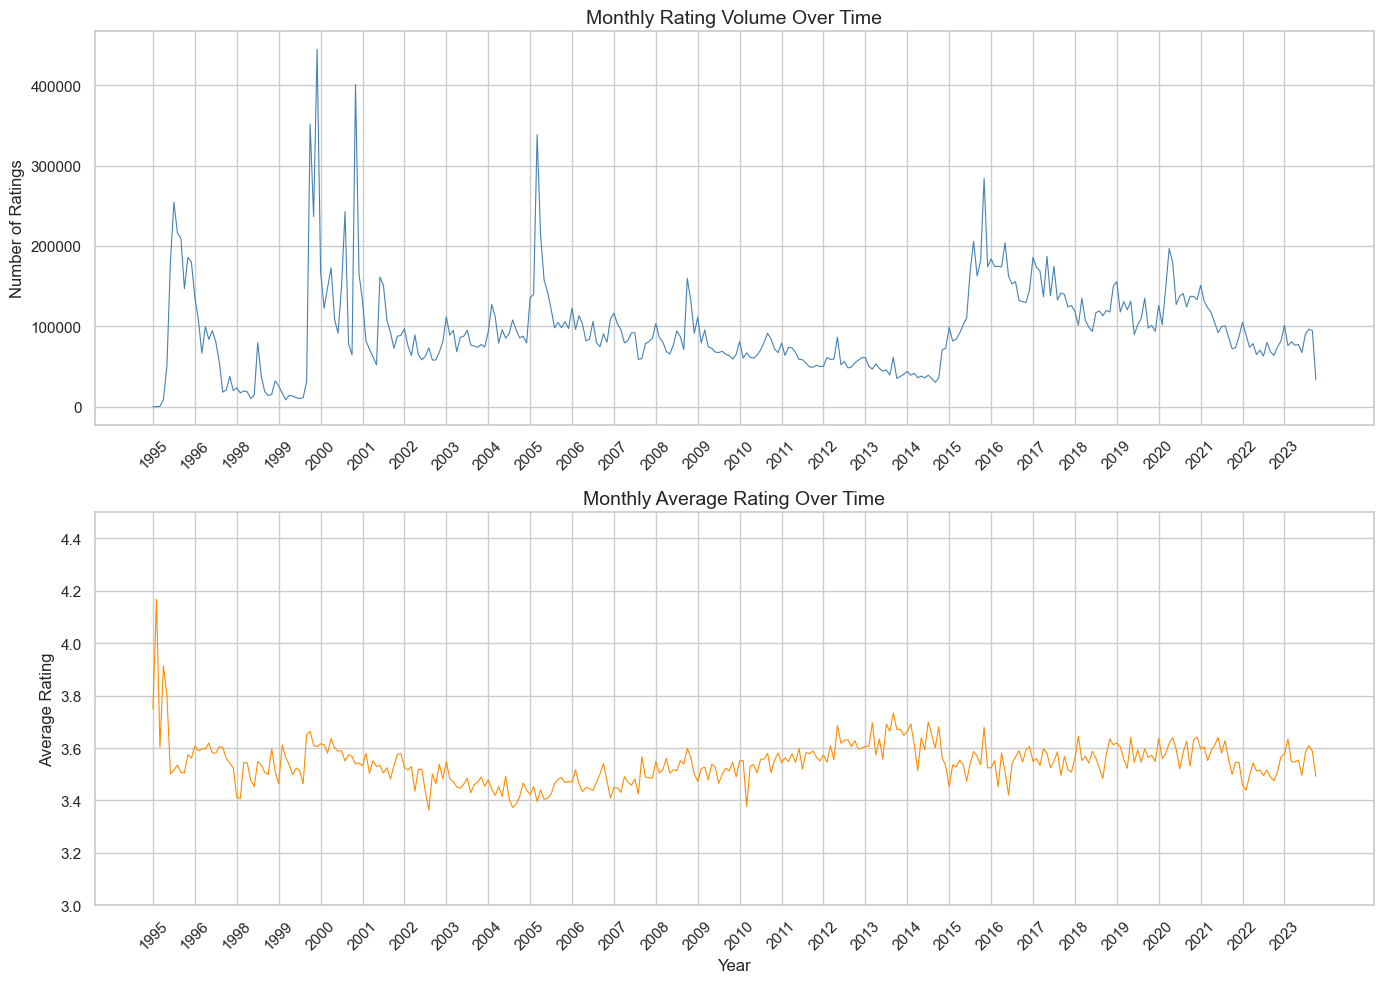

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(
    range(len(ratings_over_time)),
    ratings_over_time["num_ratings"].to_list(),
    color="steelblue", linewidth=0.8
)
axes[0].set_title("Monthly Rating Volume Over Time", fontsize=14)
axes[0].set_ylabel("Number of Ratings", fontsize=12)
axes[0].set_xlabel("")

# Tick every 12 months
tick_positions = list(range(0, len(ratings_over_time), 12))
tick_labels = [ratings_over_time["year_month"][i][:4] for i in tick_positions]
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, rotation=45)

axes[1].plot(
    range(len(ratings_over_time)),
    ratings_over_time["avg_rating"].to_list(),
    color="darkorange", linewidth=0.8
)
axes[1].set_title("Monthly Average Rating Over Time", fontsize=14)
axes[1].set_ylabel("Average Rating", fontsize=12)
axes[1].set_xlabel("Year")
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45)
axes[1].set_ylim(3.0, 4.5)

plt.tight_layout()
plt.show()

## 8. Genre Distribution and Rating Behavior by Genre
Movies can have multiple genres (pipe-separated). We need to explode genres into rows for an accurate per-genre analysis. This section looks at genre prevalence in the catalog and whether certain genres receive systematically higher/lower ratings, useful prior information for content-based feature engineering later.

In [15]:
genres_exploded = (
    movies_lf
    .with_columns(
        pl.col("genres").str.split("|").alias("genre_list")
    )
    .explode("genre_list")
    .rename({"genre_list": "genre"})
    .select(["movieId", "genre"])
    .collect()
)

genre_counts = (
    genres_exploded
    .group_by("genre")
    .agg(pl.len().alias("num_movies"))
    .sort("num_movies", descending=True)
)

display(genre_counts)

genre,num_movies
str,u32
"""Drama""",34175
"""Comedy""",23124
"""Thriller""",11823
"""Romance""",10369
"""Action""",9668
…,…
"""War""",2325
"""Western""",1696
"""Musical""",1059


In [ ]:
genres_lf = genres_exploded.lazy()

genre_rating_stats = (
    ratings_lf
    .join(genres_lf, on="movieId", how="inner")
    .group_by("genre")
    .agg([
        pl.len().alias("num_ratings"),
        pl.col("rating").mean().alias("avg_rating"),
        pl.col("rating").median().alias("median_rating"),
        pl.col("rating").std().alias("std_rating"),
    ])
    .sort("avg_rating", descending=True)
    .collect()
)

display(genre_rating_stats)

genre,num_ratings,avg_rating,median_rating,std_rating
str,u32,f32,f32,f32
"""Film-Noir""",304710,3.915774,4.0,0.912682
"""War""",1594110,3.791699,4.0,0.98859
"""Crime""",5373051,3.691771,4.0,1.005832
"""Documentary""",427353,3.691181,4.0,1.02658
"""Drama""",13973271,3.682454,4.0,0.996152
…,…,…,…,…
"""Action""",9665213,3.476407,3.5,1.070222
"""Children""",2731841,3.439241,3.5,1.096758
"""Comedy""",11206926,3.432386,3.5,1.081826


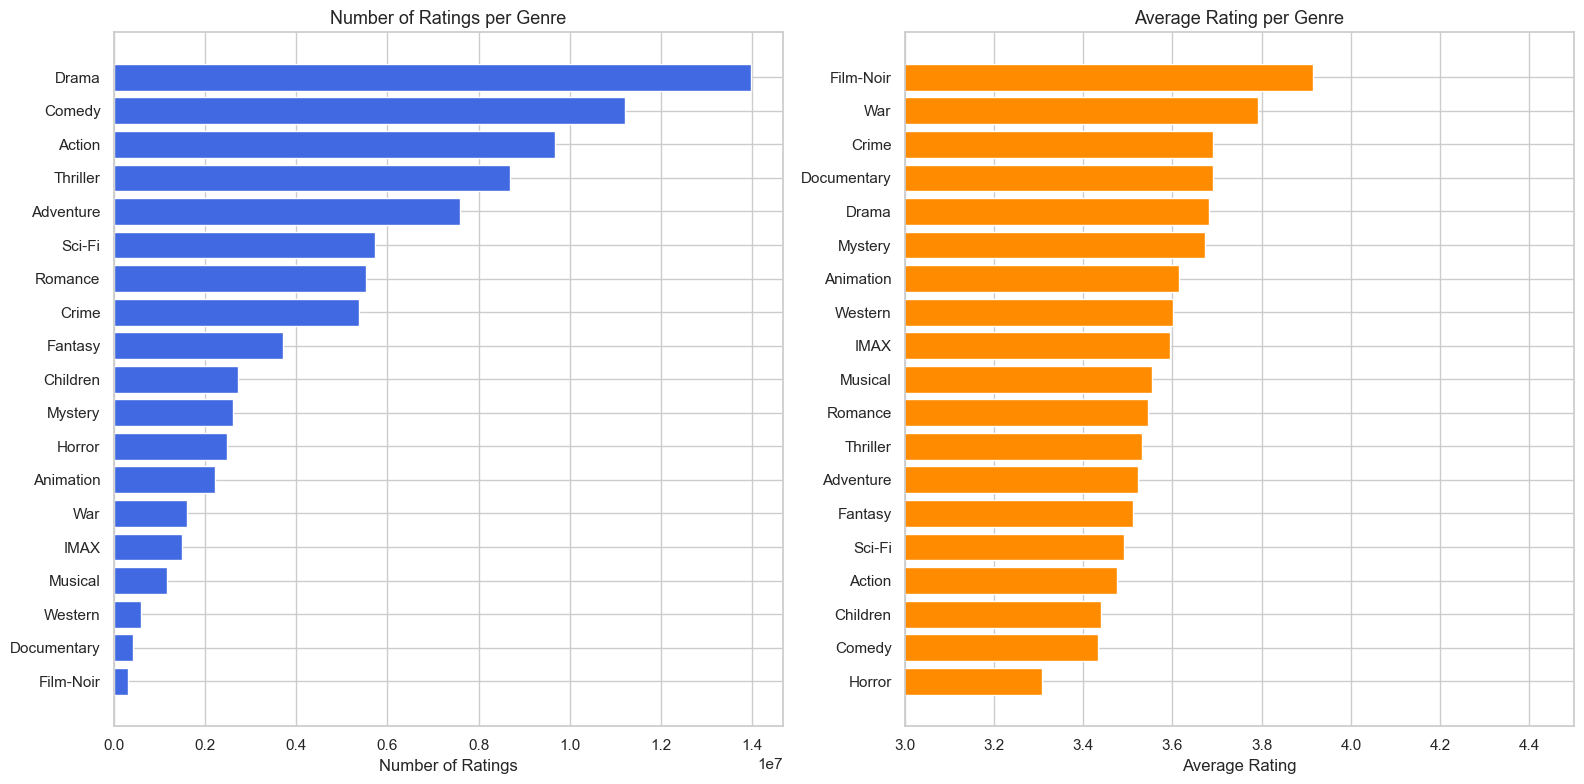

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Filter out "(no genres listed)"
plot_data = genre_rating_stats.filter(pl.col("genre") != "(no genres listed)")

genres_sorted = plot_data.sort("num_ratings", descending=True)
axes[0].barh(genres_sorted["genre"].to_list(), genres_sorted["num_ratings"].to_list(), color="royalblue")
axes[0].set_title("Number of Ratings per Genre", fontsize=13)
axes[0].set_xlabel("Number of Ratings")
axes[0].invert_yaxis()

genres_sorted_rating = plot_data.sort("avg_rating", descending=True)
axes[1].barh(genres_sorted_rating["genre"].to_list(), genres_sorted_rating["avg_rating"].to_list(), color="darkorange")
axes[1].set_title("Average Rating per Genre", fontsize=13)
axes[1].set_xlabel("Average Rating")
axes[1].set_xlim(3.0, 4.5)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Cold Start Filtering Thresholds
Before modeling, we typically apply k-core filtering (keep only users with ≥ k ratings and movies with ≥ k ratings, iteratively) to reduce sparsity and cold-start noise. Let's quantify how much data survives under various minimum-interaction thresholds so we can make an informed decision when building the interaction matrix.

This is purely analytical here, no data is dropped yet.

In [19]:
thresholds = [5, 10, 20, 50]

results = []
for k in thresholds:
    filtered = (
        ratings_lf
        .join(
            ratings_lf.group_by("movieId").agg(pl.len().alias("m_count"))
                      .filter(pl.col("m_count") >= k).select("movieId"),
            on="movieId", how="inner"
        )
        .join(
            ratings_lf.group_by("userId").agg(pl.len().alias("u_count"))
                      .filter(pl.col("u_count") >= k).select("userId"),
            on="userId", how="inner"
        )
        .select([
            pl.col("userId").n_unique().alias("users"),
            pl.col("movieId").n_unique().alias("movies"),
            pl.len().alias("ratings")
        ])
        .collect()
    )
    u, m, r = filtered["users"][0], filtered["movies"][0], filtered["ratings"][0]
    sparsity_k = 1 - r / (u * m)
    results.append({
        "min_k": k,
        "users": u,
        "movies": m,
        "ratings": r,
        "sparsity": round(sparsity_k * 100, 4)
    })

threshold_df = pl.DataFrame(results)
display(threshold_df)

min_k,users,movies,ratings,sparsity
i64,i64,i64,i64,f64
5,200948,43884,31921467,99.638
10,200948,31961,31842705,99.5042
20,200948,23350,31725920,99.3238
50,128344,16034,29210880,98.5805


## 10. Tag Analysis
Tags are user-generated metadata and are a key input for content-based and hybrid models. Let's look at tag frequency distribution, most common tags, and how many movies have at least one tag (coverage).

In [20]:
tag_stats = (
    tags_lf
    .select([
        pl.col("userId").n_unique().alias("unique_taggers"),
        pl.col("movieId").n_unique().alias("tagged_movies"),
        pl.col("tag").n_unique().alias("unique_tags"),
        pl.len().alias("total_tag_applications")
    ])
    .collect()
)

tagged_coverage = tag_stats["tagged_movies"][0] / n_movies
print(f"Unique taggers:            {tag_stats['unique_taggers'][0]:,}")
print(f"Unique tags:               {tag_stats['unique_tags'][0]:,}")
print(f"Total tag applications:    {tag_stats['total_tag_applications'][0]:,}")
print(f"Movies with ≥1 tag:        {tag_stats['tagged_movies'][0]:,} ({tagged_coverage:.1%} of catalog)")

Unique taggers:            15,848
Unique tags:               140,981
Total tag applications:    2,000,072
Movies with ≥1 tag:        51,323 (60.8% of catalog)


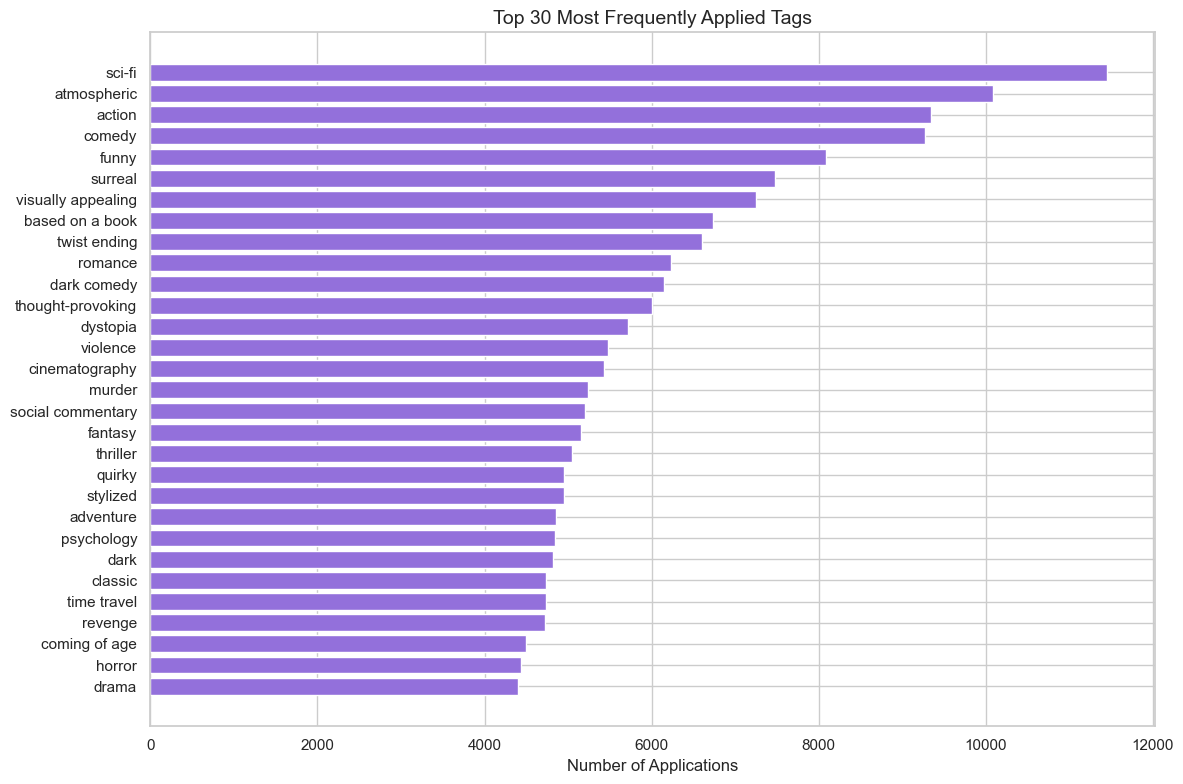

In [21]:
top_tags = (
    tags_lf
    .with_columns(pl.col("tag").str.to_lowercase().str.strip_chars())
    .group_by("tag")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(30)
    .collect()
)

plt.figure(figsize=(12, 8))
plt.barh(top_tags["tag"].to_list()[::-1], top_tags["count"].to_list()[::-1], color="mediumpurple")
plt.title("Top 30 Most Frequently Applied Tags", fontsize=14)
plt.xlabel("Number of Applications", fontsize=12)
plt.tight_layout()
plt.show()

## 11. Global Bias and Per-User / Per-Movie Mean Ratings
Matrix Factorization models (SVD, ALS, etc.) decompose the residual after subtracting global, user, and item biases. It's worth visualising the distributions of per-user and per-movie mean ratings to understand the magnitude of these biases before modeling.

In [22]:
global_mean = ratings_lf.select(pl.col("rating").mean()).collect().item()
print(f"Global mean rating: {global_mean:.4f}")

user_means = (
    ratings_lf
    .group_by("userId")
    .agg(pl.col("rating").mean().alias("user_mean"))
    .collect()
)

movie_means = (
    ratings_lf
    .group_by("movieId")
    .agg(
        pl.col("rating").mean().alias("movie_mean"),
        pl.len().alias("n_ratings")
    )
    .collect()
)

Global mean rating: 3.5404


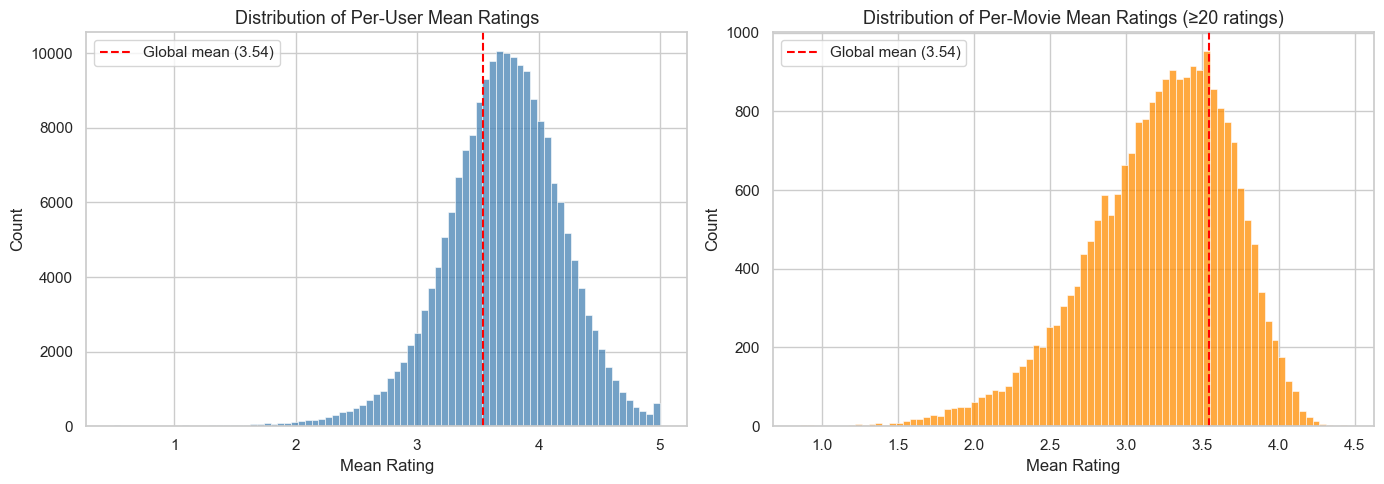

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(user_means["user_mean"].to_list(), bins=80, color="steelblue", ax=axes[0])
axes[0].axvline(global_mean, color="red", linestyle="--", label=f"Global mean ({global_mean:.2f})")
axes[0].set_title("Distribution of Per-User Mean Ratings", fontsize=13)
axes[0].set_xlabel("Mean Rating")
axes[0].legend()

# Filter to movies with ≥20 ratings for a stable estimate
movie_means_filtered = movie_means.filter(pl.col("n_ratings") >= 20)
sns.histplot(movie_means_filtered["movie_mean"].to_list(), bins=80, color="darkorange", ax=axes[1])
axes[1].axvline(global_mean, color="red", linestyle="--", label=f"Global mean ({global_mean:.2f})")
axes[1].set_title("Distribution of Per-Movie Mean Ratings (≥20 ratings)", fontsize=13)
axes[1].set_xlabel("Mean Rating")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. EDA Summary & Modeling Implications

| Finding | Value | Implication |
|---|---|---|
| Matrix sparsity | 99.81% (200,948 users × 84,432 movies, 32M ratings) | Mandatory sparse CSR/COO representation; dense MF factorisation only viable post k-core pruning |
| Long tail | Median movie has 5 ratings; 75th pct = 25; max = 102,929 (Shawshank) | k=20 core retains 99.3% of ratings while halving the item space to ~23K movies, reasonable default threshold |
| Rating distribution | Right-skewed; modal bin = 4.0 stars; global mean = 3.54; half-star increments used less than whole-star | Explicit feedback setting; substantial positive bias, global/user/item bias terms will absorb a large share of the signal before latent factors even fire |
| User activity | min=20, median=73, p95=571, p99.9=2,995; heavy-tailed | No hard cap needed for MF, but watch ALS confidence weights for power users; consider log-scaling interaction counts for implicit variants |
| Temporal span | 1995–2023 (~28 years); volume grows then plateaus post-2015 | Use temporal train/val/test split (e.g. last 10% of timestamps as test) rather than random split to avoid leakage; TimeSVD++ or temporal embeddings are worth a late-stage experiment |
| Genre rating bias | Film-Noir and Documentary rate highest; Horror and Children's rate lowest; Drama dominates volume | Genre is a useful side-information feature for LightFM / factorisation machines; can also serve as a content-based cold-start signal |
| Tag coverage | 60.8% of catalog (51,323 / 84,432 movies); 140,981 unique tags; only 15,848 distinct taggers | Tag-based content features (TF-IDF, tag2vec) viable for the majority of the catalog but will miss ~40% of items, hybrid model must fall back to CF for untagged items |
| k-core retention | k=5: 43,884 items / 99.64% sparsity → k=20: 23,350 items / 99.32% sparsity | k=20 is a good default; evaluate NDCG@10 on held-out users across thresholds to confirm no significant recall degradation |